In [1]:
from functools import partial
import numpy as np
import jax
import jax.numpy as jnp
from jax import vmap, jit
from jax_grid import Grid
from jax_helpers import gg_space, glob_inh, sigmoid, softmax
from jax_scaffold import Scaffold
from tqdm import tqdm
import matplotlib.pyplot as plt

# Grid only

In [ ]:
exc_range = np.arange(0, 101)
inh_range = np.arange(0, -101, -1)
lambdas = np.array([3,4,5])
Ng = np.sum(lambdas**2)

wggs = gg_space(Ng, lambdas, exc_range, inh_range, 'g2g_space.npy')
print('saved all weight matrices!')

saved all weight matrices!


## Quadratic normalization

In [ ]:
lambdas = np.array([3, 4, 5])
lambdas_static = tuple(int(l) for l in lambdas)

g0_jax = jnp.asarray(Grid(lambdas, 'sigmoid', gg_exc=0, gg_inh=0).grid)

wggs = np.load('g2g_space.npy')                           # (100, 100, Ng, Ng)
wggs_flat = jnp.asarray(wggs).reshape(-1, *wggs.shape[-2:])  # (10000, Ng, Ng)

vmapped_run = jax.jit(
    jax.vmap(Grid.simulate_run, in_axes=(None, {'W_gg': 0}, None, None, None, None)),
    static_argnames=('lambdas', 'activation'),
)

def score_all(activation_fn, chunk_size=500):
    chunks = []
    for start in tqdm(range(0, wggs_flat.shape[0], chunk_size)):
        batch = wggs_flat[start:start + chunk_size]
        final = vmapped_run(g0_jax, {'W_gg': batch}, lambdas_static, 1.0, activation_fn, 0.1)
        correct = jnp.all(jnp.abs(final - g0_jax[None]) <= 1e-1, axis=1)  # (chunk, patts)
        chunks.append(np.asarray(jnp.mean(correct, axis=1)))
    return np.concatenate(chunks).reshape(len(exc_range), len(inh_range))

fracs_q  = score_all(glob_inh)

100%|██████████| 21/21 [10:25<00:00, 29.79s/it]


In [ ]:
np.save('fracs_q.npy', fracs_q)

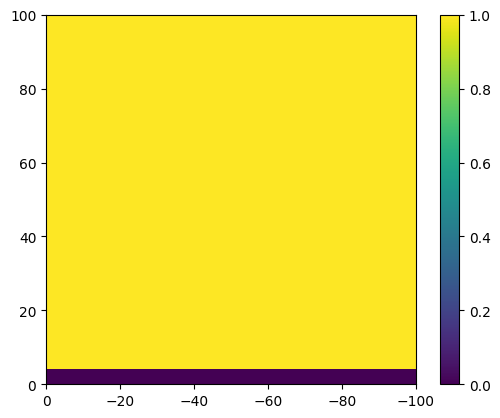

In [ ]:
fracs_q = np.load('fracs_q.npy')
plt.imshow(fracs_q, extent=[0, -100, 0, 100], origin='lower')
plt.colorbar()

In [ ]:
plt.imshow(fracs_q[:5, :5], origin='lower')

In [ ]:
g0_jax = jnp.asarray(Grid(lambdas, 'sigmoid', gg_exc=0, gg_inh=0).grid)

mean_g_norm = np.mean(np.linalg.norm(g0, axis=0))  
noise = np.random.normal(0, 1, g0.shape) / np.sqrt(scaffold.Ng) 
g0_noisy = g0 + noise_val * noise * mean_g_norm

## Sigmoid

In [ ]:
fracs_sig = score_all(sigmoid)

100%|██████████| 21/21 [07:33<00:00, 21.57s/it]


In [ ]:
np.save('fracs_sig.npy', fracs_sig)

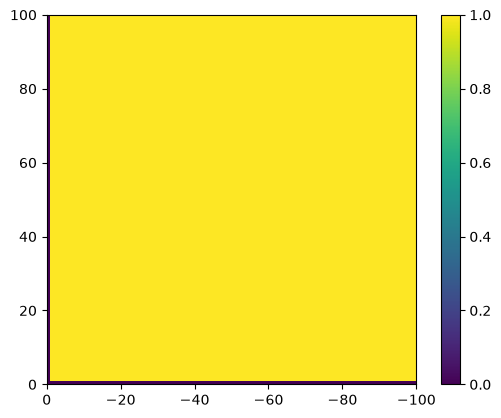

In [26]:
fracs_sig = np.load('fracs_sig.npy')
plt.imshow(fracs_sig, extent=[0, -100, 0, 100], origin='lower')
plt.colorbar()

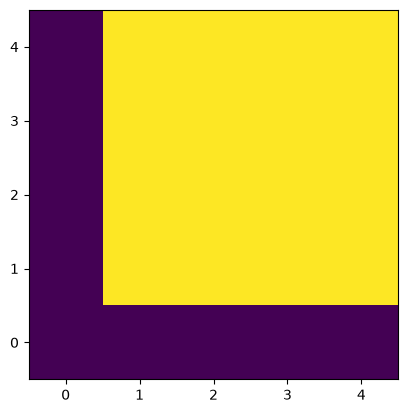

In [29]:
plt.imshow(fracs_sig[:5, :5], origin='lower')

## Softmax

In [ ]:
fracs_soft = score_all(softmax)

100%|██████████| 21/21 [12:45<00:00, 36.46s/it]


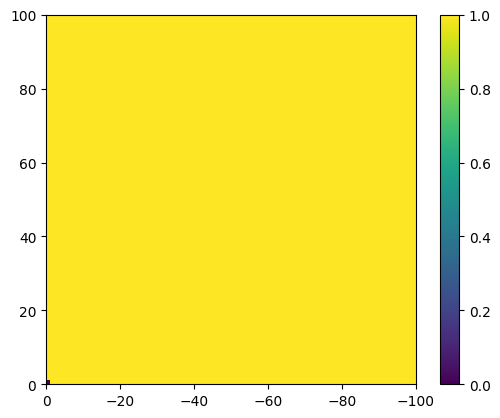

In [ ]:
fracs_soft = np.load('fracs_soft.npy')
plt.imshow(fracs_soft, extent=[0, -100, 0, 100], origin='lower')
plt.colorbar()

# Scaffold

In [ ]:
@partial(jax.jit, static_argnames=('lambdas', 'activation'))
def run_and_score_chunk(g0, h0, weights, lambdas, b, tau_g, tau_h, activation, dt, h0_norm):
    final_g, final_h = jax.vmap(
        Scaffold.simulate_run,
        in_axes=(None, None, {'W_gg': 0, 'W_gh': None, 'W_hg': None}, None, None, None, None, None, None),
    )(g0, h0, weights, lambdas, b, tau_g, tau_h, activation, dt)

    grid_err = jnp.max(jnp.abs(final_g - g0[None]), axis=1)
    hc_err   = jnp.linalg.norm(final_h - h0[None], axis=1) / h0_norm[None]
    return grid_err, hc_err

## g0, h0 = patterns

### Sigmoid

In [ ]:
lambdas = np.array([3, 4, 5])
lambdas_static = tuple(int(l) for l in lambdas)
scaffold = Scaffold(400, lambdas, 'sigmoid', gg_exc=0, gg_inh=0, gamma=0.6)

g0_jax = jnp.asarray(scaffold.grid)
h0_jax = jnp.asarray(scaffold.hc)
h0_norm   = jnp.linalg.norm(h0_jax, axis=0)

wggs = np.load('g2g_space.npy')                              # (100, 100, Ng, Ng)
wggs_flat = jnp.asarray(wggs).reshape(-1, *wggs.shape[-2:])  # (10000, Ng, Ng)

def score_scaffold(activation_fn, chunk_size=200):
    grid_chunks, hc_chunks = [], []
    for start in tqdm(range(0, wggs_flat.shape[0], chunk_size)):
        batch = wggs_flat[start:start + chunk_size]
        weights_batch = {'W_gg': batch, 'W_gh': scaffold.weights['W_gh'], 'W_hg': scaffold.weights['W_hg']}

        grid_err, hc_err = run_and_score_chunk(
            g0_jax, h0_jax, weights_batch, lambdas_static,
            scaffold.b, scaffold.tau_g, scaffold.tau_h, activation_fn, scaffold.dt, h0_norm,
        )
        grid_chunks.append(np.asarray(grid_err))  # pulls to host RAM, frees GPU mem for next chunk
        hc_chunks.append(np.asarray(hc_err))

    grid_errors = np.concatenate(grid_chunks).reshape(len(exc_range), len(inh_range), -1)
    hc_errors   = np.concatenate(hc_chunks).reshape(len(exc_range), len(inh_range), -1)
    return grid_errors, hc_errors


g_errs, h_errs  = score_scaffold(sigmoid)

100%|██████████| 52/52 [36:19<00:00, 41.90s/it]


In [ ]:
np.save('scaff_sig_g.npy', g_errs)
np.save('scaff_sig_h.npy', h_errs)

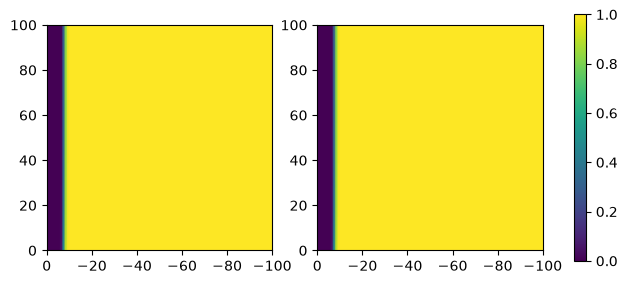

In [33]:
scaff_sig_g = np.load('scaff_sig_g.npy')
scaff_sig_h = np.load('scaff_sig_h.npy')
grid_thresh, hc_thresh = 0.1, 0.1

frac_grid_sig = np.mean(scaff_sig_g < grid_thresh, axis=-1)
frac_hc_sig   = np.mean(scaff_sig_h < hc_thresh, axis=-1)


fig, ax = plt.subplots(1, 2, figsize=(8,8))
ax[0].imshow(frac_grid_sig, extent=[0, -100, 0, 100], origin='lower')
im = ax[1].imshow(frac_hc_sig, extent=[0, -100, 0, 100], origin='lower')
cbar = fig.colorbar(im, ax=ax, shrink=0.4, pad=0.05)

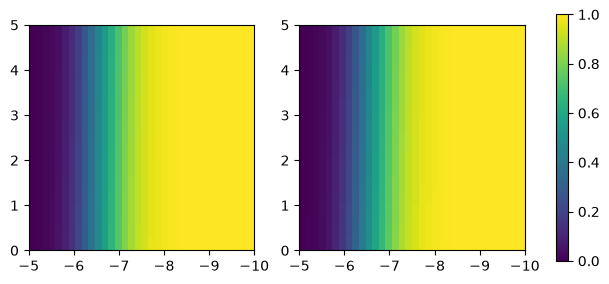

In [114]:
# Finer parameter search
scaff_sig_g0 = np.load('/home/srujana/VSCode Projects/Thesis/vectorHASH-cont-jax/parameter_search_results/scaff_sig_g_finer.npy')
scaff_sig_h0 = np.load('/home/srujana/VSCode Projects/Thesis/vectorHASH-cont-jax/parameter_search_results/scaff_sig_h_finer.npy')
grid_thresh, hc_thresh = 0.01, 0.1

frac_grid_sig = np.mean(scaff_sig_g0 < grid_thresh, axis=-1)
frac_hc_sig = np.mean(scaff_sig_h0 < hc_thresh, axis=-1)

fig, ax = plt.subplots(1, 2, figsize=(8,8))
im0 = ax[0].imshow(frac_grid_sig, extent=[-5, -10, 0, 5], origin='lower', vmin=0, vmax=1)
im = ax[1].imshow(frac_hc_sig, extent=[-5, -10, 0, 5], origin='lower', vmin=0, vmax=1)
cbar = fig.colorbar(im, ax=ax, shrink=0.4, pad=0.05)

In [ ]:
exc_range = np.arange(0, 5, 0.15)
inh_range = np.arange(-5, -10, -0.15)
print(frac_grid_sig[1, :])
print(inh_range[-6])

[0.002 0.006 0.016 0.029 0.052 0.091 0.142 0.212 0.294 0.386 0.479 0.567
 0.654 0.737 0.808 0.866 0.907 0.937 0.961 0.972 0.984 0.992 0.996 0.997
 0.998 0.999 0.999 1.    1.    1.    1.    1.    1.    1.   ]
-8.90000000000001


### Quadratic normalization

In [ ]:
g_errs_q, h_errs_q  = score_scaffold(sigmoid)

100%|██████████| 52/52 [36:12<00:00, 41.79s/it]


In [ ]:
np.save('scaff_q_g.npy', g_errs_q)
np.save('scaff_q_h.npy', h_errs_q)

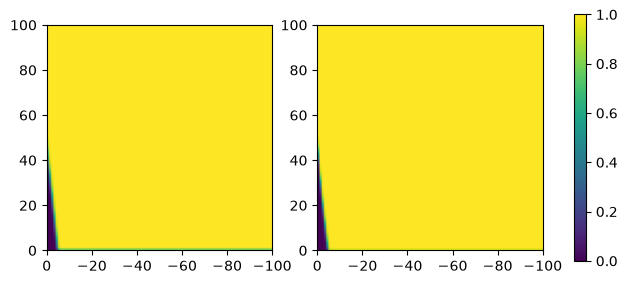

In [55]:
scaff_q_g = np.load('scaff_q_g.npy')
scaff_q_h = np.load('scaff_q_h.npy')
grid_thresh, hc_thresh = 0.1, 0.1

frac_grid_q = np.mean(scaff_q_g < grid_thresh, axis=-1)
frac_hc_q  = np.mean(scaff_q_h < hc_thresh, axis=-1)

fig, ax = plt.subplots(1, 2, figsize=(8,8))
ax[0].imshow(frac_grid_q, extent=[0, -100, 0, 100], origin='lower')
im = ax[1].imshow(frac_hc_q, extent=[0, -100, 0, 100], origin='lower')
cbar = fig.colorbar(im, ax=ax, shrink=0.4, pad=0.05)

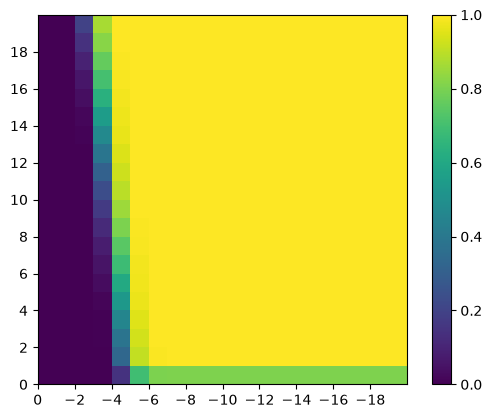

In [57]:
plt.imshow(frac_grid_q[:20, :20], extent=[0, -20, 0, 20], origin='lower')
plt.xticks(np.arange(0, -20, -2))
plt.yticks(np.arange(0, 20, 2))
plt.colorbar()
plt.show()

### Softmax

In [ ]:
g_errs_soft, h_errs_soft  = score_scaffold(softmax)

100%|██████████| 52/52 [38:08<00:00, 44.00s/it]


In [ ]:
np.save('scaff_soft_g.npy', g_errs_soft)
np.save('scaff_soft_h.npy', h_errs_soft)

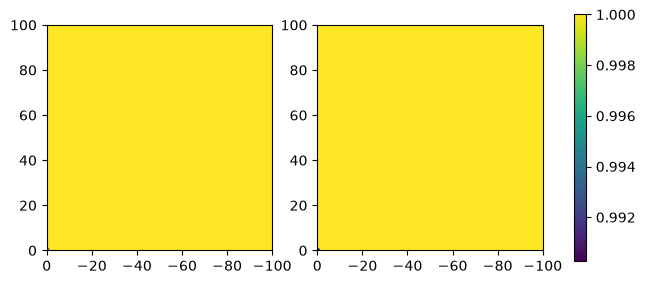

In [58]:
scaff_soft_g = np.load('scaff_soft_g.npy')
scaff_soft_h = np.load('scaff_soft_h.npy')
grid_thresh, hc_thresh = 0.01, 0.01

frac_grid_soft = np.mean(scaff_soft_g < grid_thresh, axis=-1)
frac_hc_soft   = np.mean(scaff_soft_h < hc_thresh, axis=-1)

fig, ax = plt.subplots(1, 2, figsize=(8,8))
ax[0].imshow(frac_grid_soft, extent=[0, -100, 0, 100], origin='lower')
im = ax[1].imshow(frac_hc_soft, extent=[0, -100, 0, 100], origin='lower')
cbar = fig.colorbar(im, ax=ax, shrink=0.4, pad=0.05)

## g0 = zeros, h0 = pattern

### Sigmoid

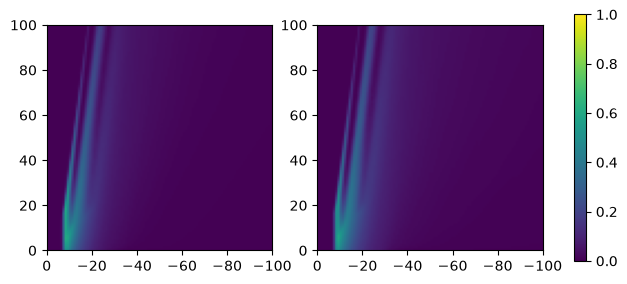

In [131]:
scaff_sig_g0 = np.load('/home/srujana/VSCode Projects/Thesis/vectorHASH-cont-jax/parameter_search_results/scaff_sig_g0s.npy')
scaff_sig_h0 = np.load('/home/srujana/VSCode Projects/Thesis/vectorHASH-cont-jax/parameter_search_results/scaff_sig_h0s.npy')
grid_thresh, hc_thresh = 0.01, 0.3

frac_grid_sig0 = np.mean(scaff_sig_g0 < grid_thresh, axis=-1)
frac_hc_sig0  = np.mean(scaff_sig_h0 < hc_thresh, axis=-1)

fig, ax = plt.subplots(1, 2, figsize=(8,8))
im0 = ax[0].imshow(frac_grid_sig0, extent=[0, -100, 0, 100], origin='lower', vmin=0, vmax=1)
im = ax[1].imshow(frac_hc_sig0, extent=[0, -100, 0, 100], origin='lower', vmin=0, vmax=1)
cbar = fig.colorbar(im, ax=ax, shrink=0.4, pad=0.05)

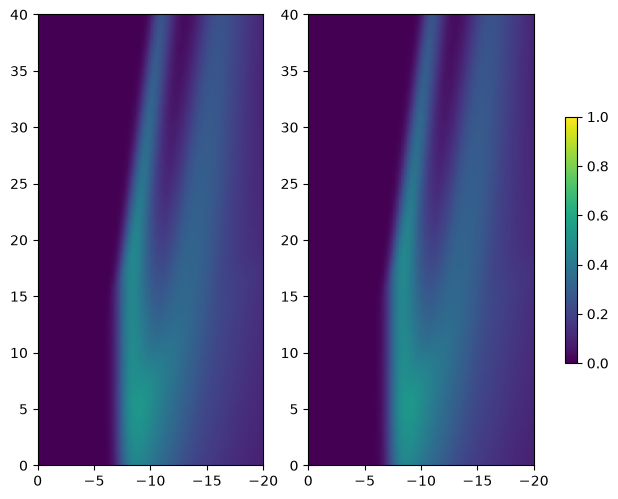

In [135]:
# Finer parameter search
scaff_sig_g0 = np.load('/home/srujana/VSCode Projects/Thesis/vectorHASH-cont-jax/parameter_search_results/scaff_sig_g0s_finer.npy')
scaff_sig_h0 = np.load('/home/srujana/VSCode Projects/Thesis/vectorHASH-cont-jax/parameter_search_results/scaff_sig_h0s_finer.npy')
grid_thresh, hc_thresh = 0.01, 0.5

frac_grid_sig0 = np.mean(scaff_sig_g0 < grid_thresh, axis=-1)
frac_hc_sig0  = np.mean(scaff_sig_h0 < hc_thresh, axis=-1)

fig, ax = plt.subplots(1, 2, figsize=(8,8))
im0 = ax[0].imshow(frac_grid_sig0, extent=[0, -20, 0, 40], origin='lower', vmin=0, vmax=1)
im = ax[1].imshow(frac_hc_sig0, extent=[0, -20, 0, 40], origin='lower', vmin=0, vmax=1)
cbar = fig.colorbar(im, ax=ax, shrink=0.4, pad=0.05)

In [ ]:
best_idx = np.unravel_index(np.argmax(frac_grid_sig0), frac_grid_sig0.shape)
exc_range = np.arange(0, 40, 0.25)
inh_range = np.arange(0, -20, -0.25)
best_exc, best_inh = exc_range[best_idx[0]], inh_range[best_idx[1]]
print(f'grid best: exc={best_exc}, inh={best_inh}, frac_correct={frac_grid_sig0[best_idx]:.3f}')

best_idx = np.unravel_index(np.argmax(frac_hc_sig0), frac_hc_sig0.shape)
best_exc, best_inh = exc_range[best_idx[0]], inh_range[best_idx[1]]
print(f'hc best: exc={best_exc}, inh={best_inh}, frac_correct={frac_grid_sig0[best_idx]:.3f}')

best_wgg_idx = best_idx[0]*len(inh_range) + best_idx[1]   
print('10 worst errors:', np.sort(scaff_sig_g0[best_idx[0], best_idx[1]])[-10:])

joint_score = frac_grid_sig0 * frac_hc_sig0 
best_idx = np.unravel_index(np.argmax(joint_score), joint_score.shape)
print('best index if joint score:', exc_range[best_idx[0]], inh_range[best_idx[1]])

grid best: exc=5.0, inh=-8.75, frac_correct=0.531
hc best: exc=5.0, inh=-8.75, frac_correct=0.531
10 worst errors: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
best index if joint score: 5.0 -8.75


### Quadratic normalization

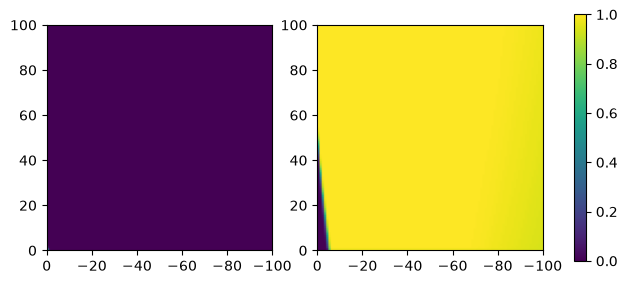

In [83]:
scaff_q_g0 = np.load('scaff_q_g0s.npy')
scaff_q_h0 = np.load('scaff_q_h0s.npy')
grid_thresh, hc_thresh = 0.1, 0.1

frac_grid_q0 = np.mean(scaff_q_g0 < grid_thresh, axis=-1)
frac_hc_q0  = np.mean(scaff_q_h0 < hc_thresh, axis=-1)

fig, ax = plt.subplots(1, 2, figsize=(8,8))
im0 = ax[0].imshow(frac_grid_q0, extent=[0, -100, 0, 100], origin='lower', vmin=0, vmax=1)
im = ax[1].imshow(frac_hc_q0, extent=[0, -100, 0, 100], origin='lower', vmin=0, vmax=1)
cbar = fig.colorbar(im, ax=ax, shrink=0.4, pad=0.05)

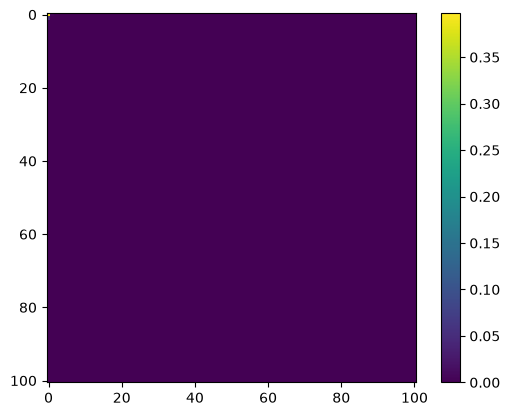

In [85]:
plt.imshow(frac_grid_q0)
plt.colorbar()